**Name:** V.Mariya Joevita

**Reg.No:** 3122235001077

**Ex8:** Effect of PCA on Regression and
Classification Models


**1. Loading Dataset**

In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Dataset.csv')
df.head()

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


**2. EDA**

In [2]:
df.info()
print("\nSamples:",df.shape[0])
print("\nFeatures:",df.shape[1])
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Math                              1000 non-null   float64
 1   Physics                           1000 non-null   float64
 2   Chemistry                         1000 non-null   float64
 3   Biology                           1000 non-null   float64
 4   Total_Science                     1000 non-null   float64
 5   Average_Science                   1000 non-null   float64
 6   English                           1000 non-null   float64
 7   Computer_Science                  1000 non-null   float64
 8   Sports_Score                      1000 non-null   float64
 9   Attendance_Percentage             1000 non-null   float64
 10  Random_Noise_Feature              1000 non-null   float64
 11  Final_Score_Regression            1000 non-null   float64
 12  Perform

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.547502,70.222492,70.099724,69.897679,280.767397,70.098374,68.910072,71.289176,60.275127,84.939829,-1.995426,66.621902
std,10.808021,11.054274,10.996436,11.300320,40.221715,10.247065,10.513340,10.939763,15.175282,4.825616,48.520180,10.243337
min,40.281107,40.714289,33.064255,34.674721,159.256015,39.353154,33.780309,36.313866,2.450167,65.387999,-161.628272,37.230851
25%,63.486805,62.489626,62.431330,62.274814,253.402127,63.235427,61.365478,63.726518,50.447182,81.783329,-34.344974,59.931376
50%,70.482400,69.858079,69.897283,69.889763,279.889174,70.056315,68.681014,71.255254,60.286860,85.021831,-2.815709,66.712433
75%,77.318218,78.032674,77.745564,77.668212,307.528100,76.963283,76.192147,79.071257,70.158061,88.253711,30.616752,73.707292
max,117.275199,108.523772,110.783442,101.770991,438.353403,109.713013,104.958147,109.904708,110.660744,98.841868,145.705461,111.586769


**3. Preprocessing**

In [3]:
#Missing values
print(df.isnull().sum())
#Result: No null values


Math                                0
Physics                             0
Chemistry                           0
Biology                             0
Total_Science                       0
Average_Science                     0
English                             0
Computer_Science                    0
Sports_Score                        0
Attendance_Percentage               0
Random_Noise_Feature                0
Final_Score_Regression              0
Performance_Level_Classification    0
dtype: int64


In [4]:
#Encode categorial target
from sklearn.preprocessing import LabelEncoder

X = df.drop(['Final_Score_Regression','Performance_Level_Classification'],axis=1)
y_reg = df['Final_Score_Regression']
y_clf = df['Performance_Level_Classification']

le = LabelEncoder()
y_clf = le.fit_transform(y_clf)


In [5]:
#Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

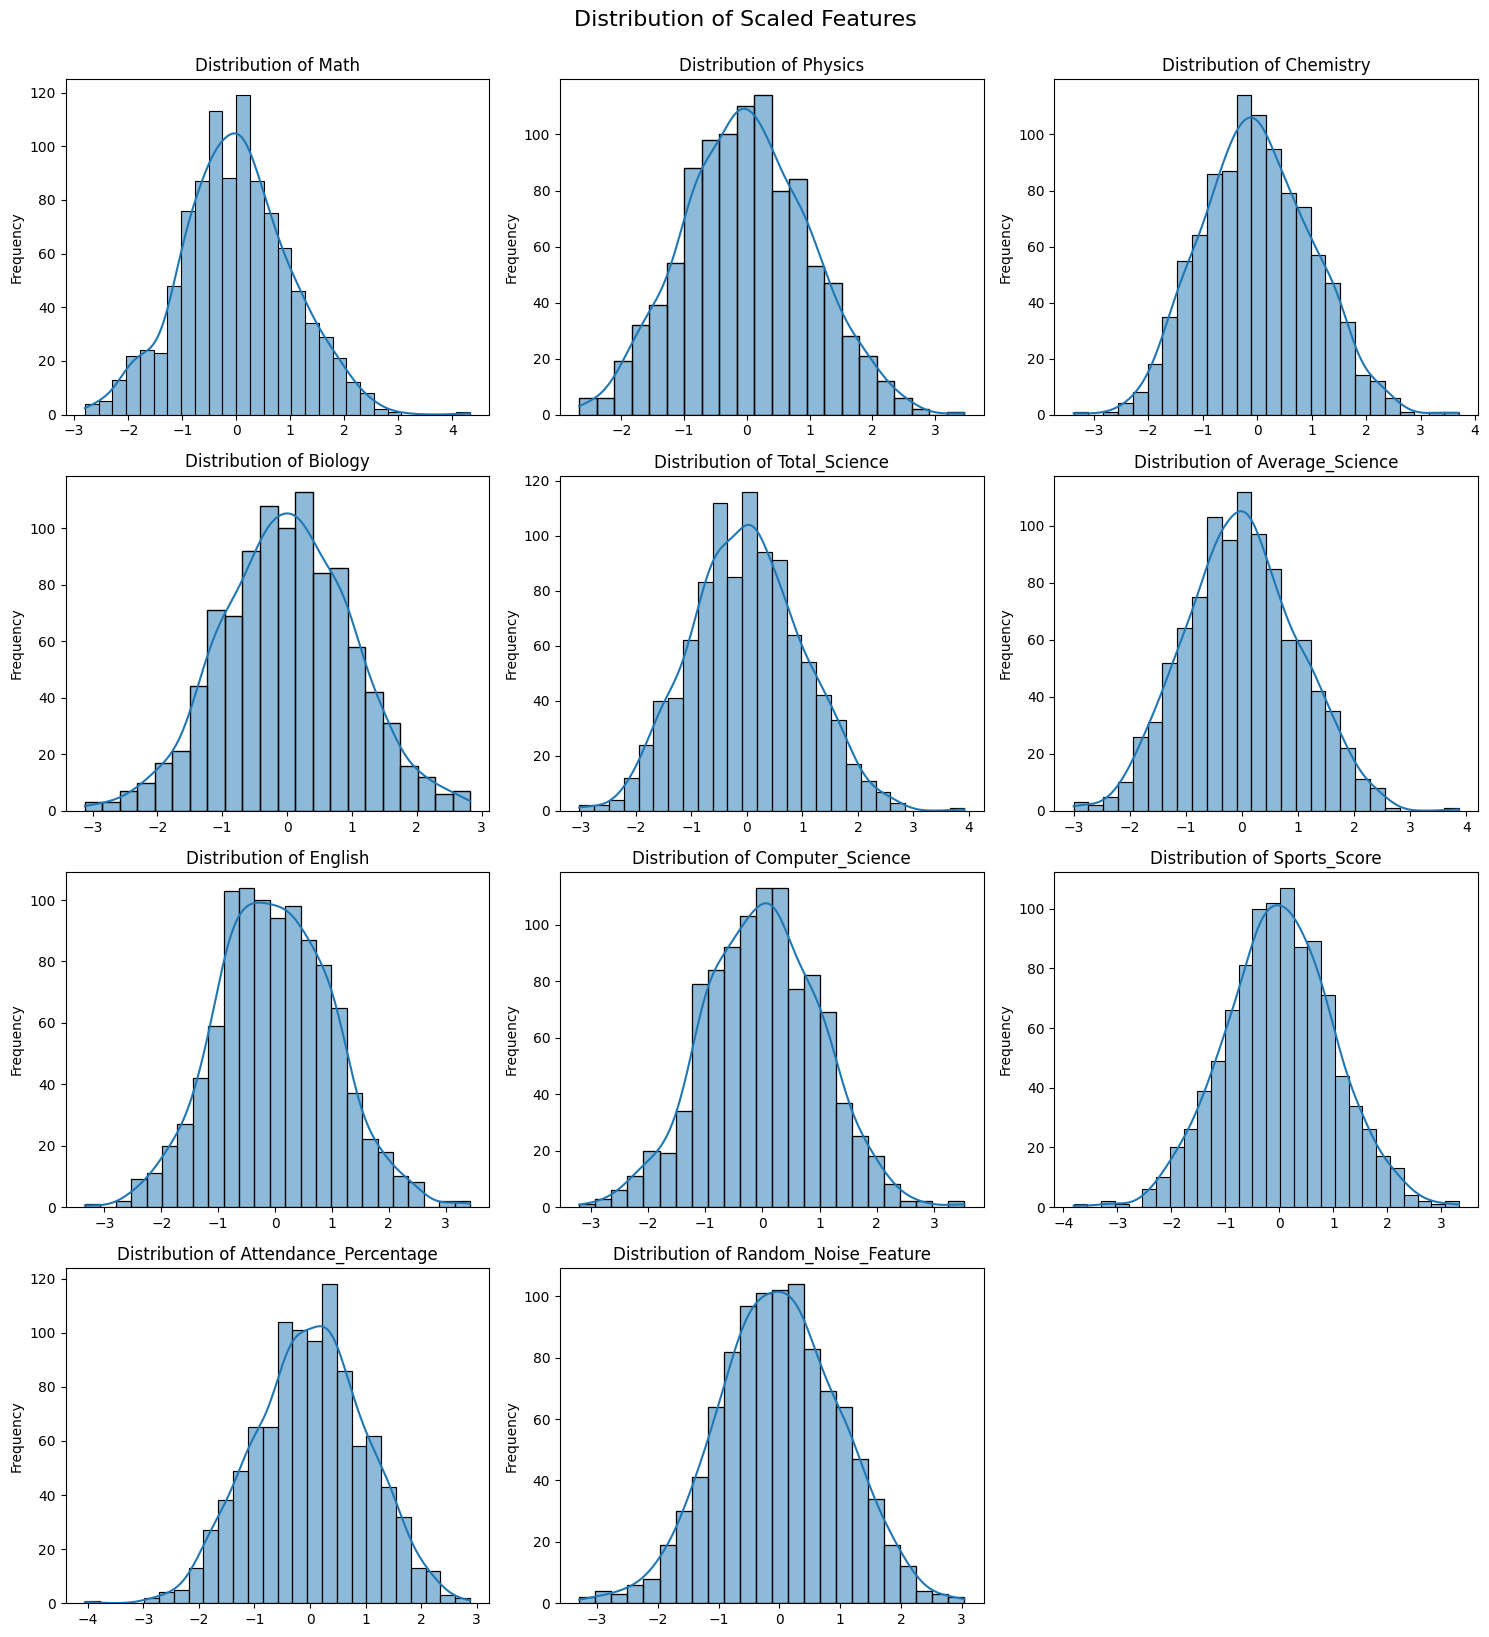

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


X_df = pd.DataFrame(X_scaled, columns=X.columns)

num_features = X_df.shape[1]
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(X_df.columns):
    sns.histplot(X_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribution of Scaled Features', y=1.02, fontsize=16)
plt.savefig('FeatureDist.png')
plt.show()


**3.1. Target Distribution Plots**

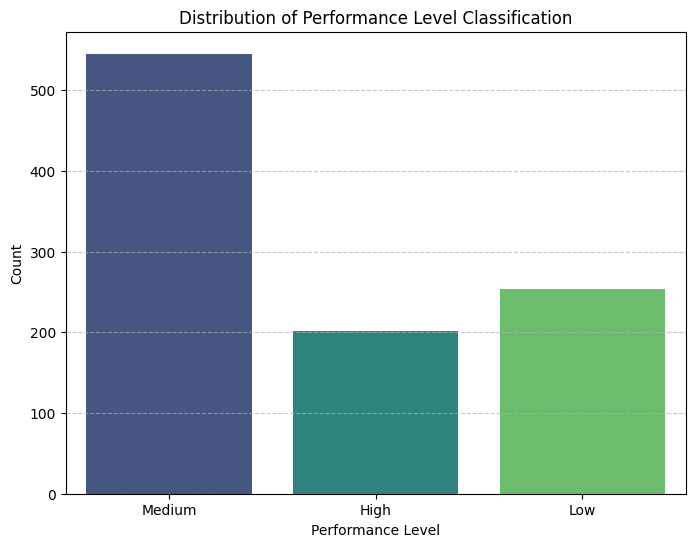

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Classification Target Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Performance_Level_Classification', hue='Performance_Level_Classification', data=df, palette='viridis', legend=False)
plt.title('Distribution of Performance Level Classification')
plt.xlabel('Performance Level')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('Classification_Target_Distribution.png')
plt.show()

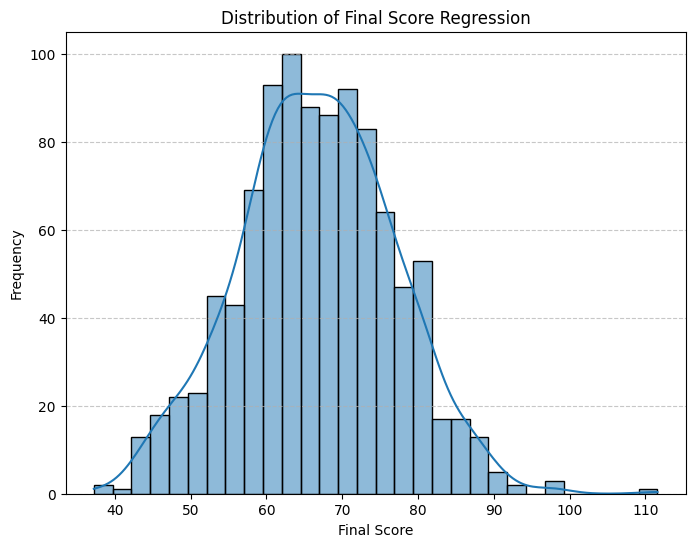

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Regression Target Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Final_Score_Regression'], kde=True, bins=30)
plt.title('Distribution of Final Score Regression')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('Regression_Target_Distribution.png')
plt.show()

**4. PCA Implementation and Scree Plot**

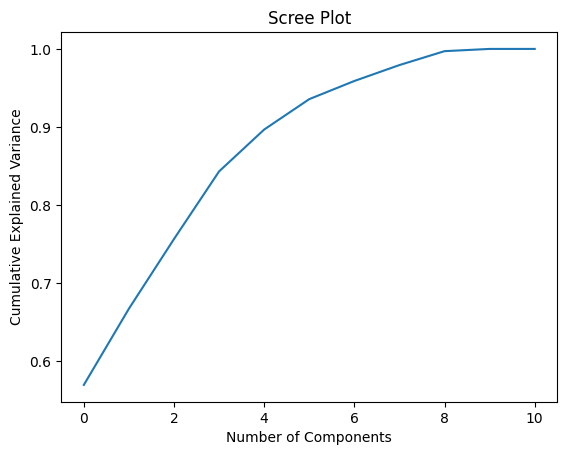

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA with all components (for scree plot)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_var = pca_full.explained_variance_ratio_

# Scree Plot
plt.plot(np.cumsum(explained_var))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.savefig('Screeplot.png')
plt.show()

In [10]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Components chosen:", pca.n_components_)
print("Explained variance:", sum(pca.explained_variance_ratio_))

Components chosen: 7
Explained variance: 0.9589522685599147


In [11]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Components chosen:", pca.n_components_)
print("Explained variance:", sum(pca.explained_variance_ratio_))

Components chosen: 7
Explained variance: 0.9589522685599147


| Components Chosen | Explained Variance (%) | Justification                                |
| :---------------- | :--------------------- | :------------------------------------------- |
| 7                 | 95.89                  | Retained components to explain 95% variance. |

**5. Regression Model Performance (with and without PCA)**

**5.1 Hyperparameter Tuning with GridSearchCV**



In [13]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression


kf = KFold(n_splits=5, shuffle=True, random_state=42)

log_reg_gs = LogisticRegression(max_iter=1000)


param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}


grid_search = GridSearchCV(estimator=log_reg_gs, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)


grid_search.fit(X_scaled, y_clf)


print(f"Best parameters for Logistic Regression: {grid_search.best_params_}")
print(f"Best cross-validation accuracy for Logistic Regression: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for Logistic Regression: {'C': 0.01}
Best cross-validation accuracy for Logistic Regression: 0.7480


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

lr = LinearRegression()

# Without PCA
mse_no_pca = -cross_val_score(lr, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
r2_no_pca = cross_val_score(lr, X_scaled, y_reg, cv=kf, scoring='r2').mean()

# With PCA
mse_pca = -cross_val_score(lr, X_pca, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
r2_pca = cross_val_score(lr, X_pca, y_reg, cv=kf, scoring='r2').mean()

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Without PCA
rf_mse_no_pca = cross_val_score(rf, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
rf_r2_no_pca = cross_val_score(rf, X_scaled, y_reg, cv=kf, scoring='r2').mean()

# With PCA
rf_mse_pca = -cross_val_score(rf, X_pca, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
rf_r2_pca = cross_val_score(rf, X_pca, y_reg, cv=kf, scoring='r2').mean()

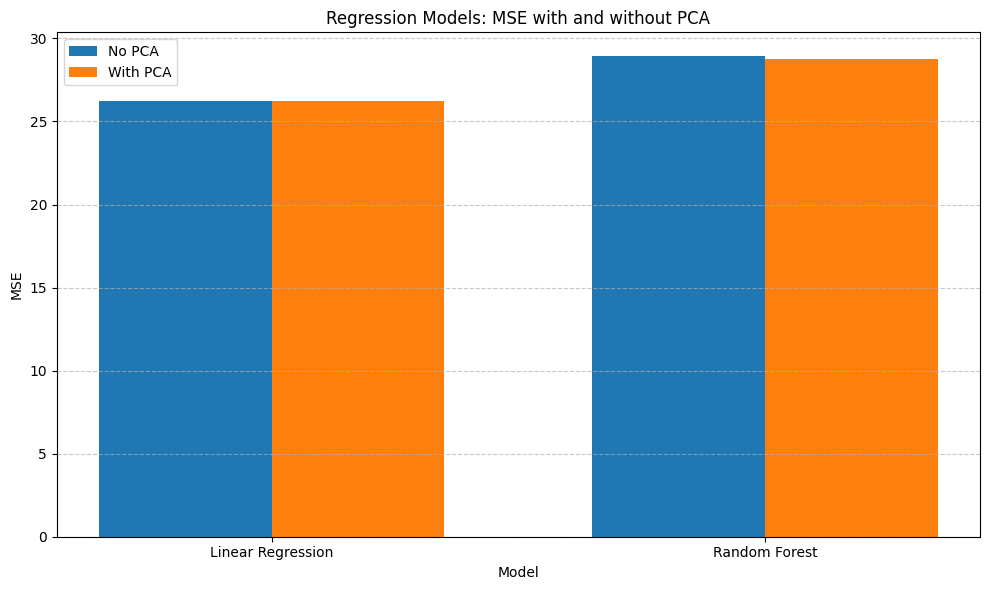

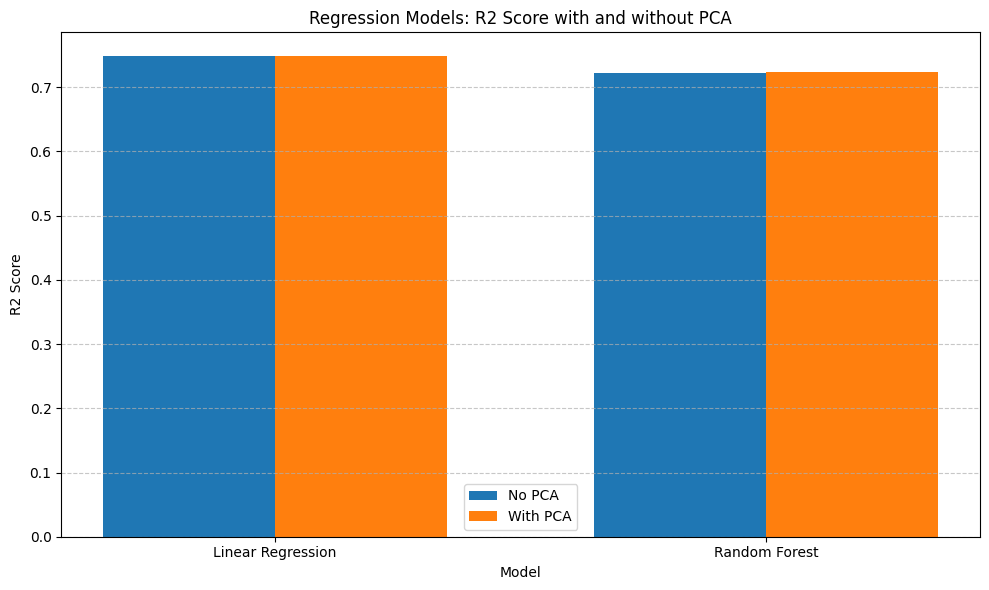

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

regression_data = {
    'Model': ['Linear Regression', 'Linear Regression', 'Random Forest', 'Random Forest'],
    'Metric': ['MSE', 'R2', 'MSE', 'R2'],
    'No PCA': [mse_no_pca, r2_no_pca, -rf_mse_no_pca, rf_r2_no_pca], # rf_mse_no_pca was negative
    'With PCA': [mse_pca, r2_pca, rf_mse_pca, rf_r2_pca]
}

regression_df = pd.DataFrame(regression_data)

# Plotting MSE
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = range(len(regression_df[regression_df['Metric'] == 'MSE']['Model']))

plt.bar([i - bar_width/2 for i in index], regression_df[regression_df['Metric'] == 'MSE']['No PCA'], bar_width, label='No PCA')
plt.bar([i + bar_width/2 for i in index], regression_df[regression_df['Metric'] == 'MSE']['With PCA'], bar_width, label='With PCA')

plt.xlabel('Model')
plt.ylabel('MSE')
plt.title('Regression Models: MSE with and without PCA')
plt.xticks(index, regression_df[regression_df['Metric'] == 'MSE']['Model'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Regression_MSE_Comparison.png')
plt.show()

# Plotting R2
plt.figure(figsize=(10, 6))
index = range(len(regression_df[regression_df['Metric'] == 'R2']['Model']))

plt.bar([i - bar_width/2 for i in index], regression_df[regression_df['Metric'] == 'R2']['No PCA'], bar_width, label='No PCA')
plt.bar([i + bar_width/2 for i in index], regression_df[regression_df['Metric'] == 'R2']['With PCA'], bar_width, label='With PCA')

plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('Regression Models: R2 Score with and without PCA')
plt.xticks(index, regression_df[regression_df['Metric'] == 'R2']['Model'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Regression_R2_Comparison.png')
plt.show()

**6. Classification Model Performance (with and without PCA)**

In [20]:


kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

# Without PCA
acc_no_pca = cross_val_score(log_reg, X_scaled, y_clf, cv=kf, scoring='accuracy').mean()
f1_no_pca = cross_val_score(log_reg, X_scaled, y_clf, cv=kf, scoring='f1_weighted').mean()

# With PCA
acc_pca = cross_val_score(log_reg, X_pca, y_clf, cv=kf, scoring='accuracy').mean()
f1_pca = cross_val_score(log_reg, X_pca, y_clf, cv=kf, scoring='f1_weighted').mean()

In [22]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

# Without PCA
svm_acc_no_pca = cross_val_score(svm, X_scaled, y_clf, cv=kf, scoring='accuracy').mean()
svm_f1_no_pca = cross_val_score(svm, X_scaled, y_clf, cv=kf, scoring='f1_weighted').mean()

# With PCA
svm_acc_pca = cross_val_score(svm, X_pca, y_clf, cv=kf, scoring='accuracy').mean()
svm_f1_pca = cross_val_score(svm, X_pca, y_clf, cv=kf, scoring='f1_weighted').mean()

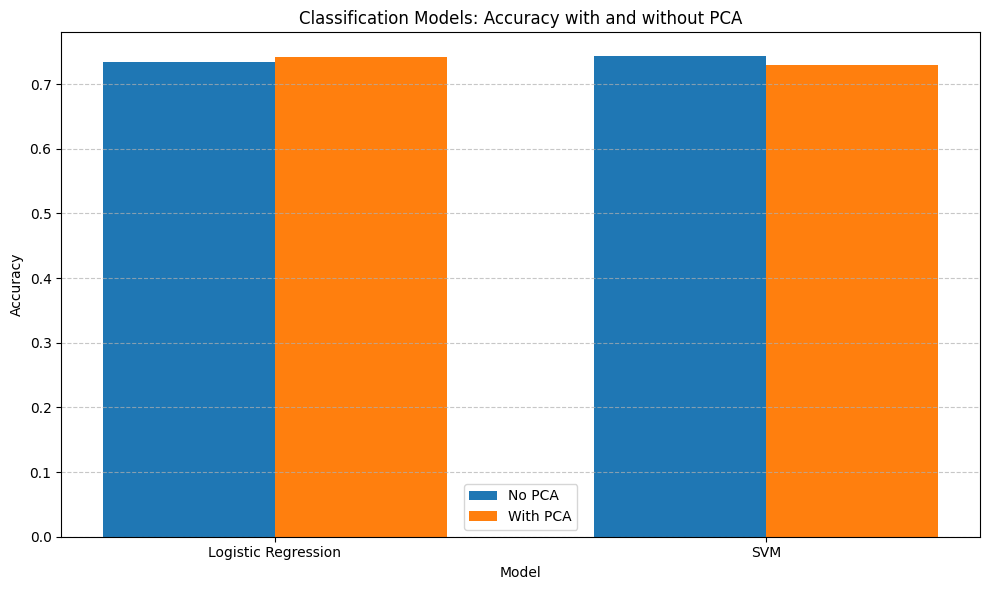

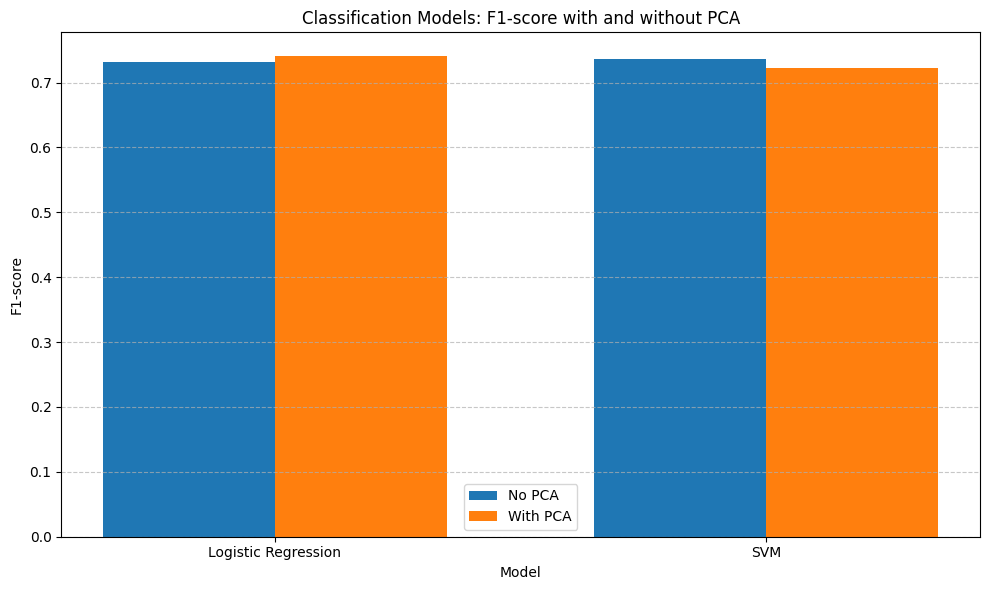

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

classification_data = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'SVM', 'SVM'],
    'Metric': ['Accuracy', 'F1-score', 'Accuracy', 'F1-score'],
    'No PCA': [acc_no_pca, f1_no_pca, svm_acc_no_pca, svm_f1_no_pca],
    'With PCA': [acc_pca, f1_pca, svm_acc_pca, svm_f1_pca]
}

classification_df = pd.DataFrame(classification_data)

# Plotting Accuracy
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = range(len(classification_df[classification_df['Metric'] == 'Accuracy']['Model']))

plt.bar([i - bar_width/2 for i in index], classification_df[classification_df['Metric'] == 'Accuracy']['No PCA'], bar_width, label='No PCA')
plt.bar([i + bar_width/2 for i in index], classification_df[classification_df['Metric'] == 'Accuracy']['With PCA'], bar_width, label='With PCA')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Classification Models: Accuracy with and without PCA')
plt.xticks(index, classification_df[classification_df['Metric'] == 'Accuracy']['Model'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Classification_Accuracy_Comparison.png')
plt.show()

# Plotting F1-score
plt.figure(figsize=(10, 6))
index = range(len(classification_df[classification_df['Metric'] == 'F1-score']['Model']))

plt.bar([i - bar_width/2 for i in index], classification_df[classification_df['Metric'] == 'F1-score']['No PCA'], bar_width, label='No PCA')
plt.bar([i + bar_width/2 for i in index], classification_df[classification_df['Metric'] == 'F1-score']['With PCA'], bar_width, label='With PCA')

plt.xlabel('Model')
plt.ylabel('F1-score')
plt.title('Classification Models: F1-score with and without PCA')
plt.xticks(index, classification_df[classification_df['Metric'] == 'F1-score']['Model'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Classification_F1_Comparison.png')
plt.show()

**7. Evaluation Metrics**

In [27]:
print("Linear Regression MSE:", mse_no_pca, mse_pca)
print("Linear Regression R2:", r2_no_pca, r2_pca)

print("Random Forest MSE:", -rf_mse_no_pca, rf_mse_pca)
print("Random Forest R2:", rf_r2_no_pca, rf_r2_pca)

print("Logistic Regression Accuracy:", acc_no_pca, acc_pca)
print("Logistic Regression F1:", f1_no_pca, f1_pca)

print("SVM Accuracy:", svm_acc_no_pca, svm_acc_pca)
print("SVM F1:", svm_f1_no_pca, svm_f1_pca)

Linear Regression MSE: 26.23384017225529 26.225062241184485
Linear Regression R2: 0.7478949690912794 0.7480707822978674
Random Forest MSE: 28.92055912298456 28.75727208065887
Random Forest R2: 0.7225411752515447 0.7240705813781908
Logistic Regression Accuracy: 0.7340000000000001 0.742
Logistic Regression F1: 0.7315055639335866 0.7403044091672106
SVM Accuracy: 0.743 0.7300000000000001
SVM F1: 0.736674341363532 0.7221100056529182


In [25]:
# Logistic Regression
print("Logistic Regression Accuracy (No PCA):", acc_no_pca)
print("Logistic Regression Accuracy (With PCA):", acc_pca)

print("Logistic Regression F1 (No PCA):", f1_no_pca)
print("Logistic Regression F1 (With PCA):", f1_pca)

# SVM
print("SVM Accuracy (No PCA):", svm_acc_no_pca)
print("SVM Accuracy (With PCA):", svm_acc_pca)

print("SVM F1 (No PCA):", svm_f1_no_pca)
print("SVM F1 (With PCA):", svm_f1_pca)

Logistic Regression Accuracy (No PCA): 0.7340000000000001
Logistic Regression Accuracy (With PCA): 0.742
Logistic Regression F1 (No PCA): 0.7315055639335866
Logistic Regression F1 (With PCA): 0.7403044091672106
SVM Accuracy (No PCA): 0.743
SVM Accuracy (With PCA): 0.7300000000000001
SVM F1 (No PCA): 0.736674341363532
SVM F1 (With PCA): 0.7221100056529182


| Model               | Metric   | Fold Avg (No PCA) | Fold Avg (With PCA) | Observation                         |
| :------------------ | :------- | :---------------- | :------------------ | :---------------------------------- |
| Linear Regression   | MSE      | 26.23             | 26.22               | Very slight improvement with PCA    |
| Linear Regression   | R2       | 0.7479            | 0.7481              | Very slight improvement with PCA    |
| Random Forest       | MSE      | 28.92             | 28.75              | Slight improvement with PCA         |
| Random Forest       | R2       | 0.7225            | 0.7241              | Slight improvement with PCA         |

| Model               | Metric   | Fold Avg (No PCA) | Fold Avg (With PCA) | Observation                    |
| :------------------ | :------- | :---------------- | :------------------ | :----------------------------- |
| Logistic Regression | Accuracy | 0.734             | 0.742               | PCA slightly improved accuracy |
| Logistic Regression | F1-score | 0.731             | 0.740               | PCA slightly improved F1-score |
| SVM                 | Accuracy | 0.743             | 0.730               | Slight decrease with PCA       |
| SVM                 | F1-score | 0.736             | 0.722               | Slight decrease with PCA       |